# Παραδείγματα

In [1]:
import ee # Google Earth Engine Python Client
import geemap # frontend του ee Google Earth Engine
from pathlib import Path # διαχείριση αρχείων
import os # για την διαχείριση περιβάλλοντος και αρχείων
from dotenv import load_dotenv # για την φόρτωση μεταβλητών περιβάλλοντος από .env αρχεία
import geopandas as gpd # για την διαχείριση γεωχωρικών δεδομένων
import pandas as pd # για την διαχείριση δεδομένων
import seaborn as sns # για την δημιουργία γραφημάτων
import matplotlib.pyplot as plt # για την δημιουργία γραφημάτων

In [2]:
# έλεγχος αν το notebook τρέχει στο google colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Colab\ Notebooks/gee
except:
  print("Παρακαλώ εκτελέστε το notebook στο Google Colab")

Παρακαλώ εκτελέστε το notebook στο Google Colab


In [ ]:

# Load environment variables from .env file
load_dotenv()
project_id = os.getenv('project_id')


# gee authentication
ee.Authenticate()
ee.Initialize(project='project_id')



OUTPUT_DIR = Path("output")


# Παράδειγμα 1: Zonal statistics

Για τις λειτουργικές αστικές περιοχές της Ευρώπης ([Functional urban area](https://www.eea.europa.eu/en/datahub/datahubitem-view/1438a2d6-ec0b-4df4-a8c4-ce83b135bfa3?activeAccordion=1083619)) να υπολογίσετε το Sum of Light ανά έτος για την από την περίοδο 2012-2021. Χρησιμοποιήστε το dataset [VIIRS Nighttime Day/Night Annual Band Composites V2.1](https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_ANNUAL_V21#bands). Να εξάγετε το αποτέλεσμα σε CSV αρχείο στο google drive. Στην συνέχεια, με την βοήθεια της βιβλιοθήκης seaborn,  να κάνετε ένα διάγραμμα της διαχρονικής μεταβολής του δείκτη SoL για τις λειτουργικές αστικές περιοχές της Ελλάδας.

In [ ]:
# Ανάγνωση των FUA από το asset του GEE
fua_asset_id = 'projects/civic-meridian-417810/assets/FUA_fixed'

# polygons
fua = ee.FeatureCollection(fua_asset_id)


# VIIRS V2.1 Annual Collection
viirs_col = ee.ImageCollection("NOAA/VIIRS/DNB/ANNUAL_V21")



In [5]:


def calculate_fua_sol(viirs_image):
    """για κάθε εικόνα VIIRS, υπολογίζει το Sum of Lights (SOL) για κάθε FUA γεωμετρία"""


    year = viirs_image.date().get('year') # λήψη του έτους από την εικόνα
    
    # επιλογή της κατάλληλης μπάντας (average_masked) από την εικόνα VIIRS
    dnb_band = viirs_image.select('average_masked')
    
    # κράτα μόνο τα pixels με τιμή φωτεινότητας > 7
    # updateMask(condition) όρισε ολο το pixel σε null όπου η condition είναι False,
    #  και διατήρησε την τιμή του pixel όπου η condition είναι True
    thresholded_lights = dnb_band.updateMask(dnb_band.gt(7))
    

    # Υπολογισμός του SoL (sum των pixels) εντός κάθε FUA γεωμετρίας
    #  οριζουμε το scale σε 463m για να ταιριάζει με την ανάλυση των VIIRS, και tileScale σε 4 (παράμετρος για καλύτερη απόδοση, default είναι 1)
    fua_stats = thresholded_lights.reduceRegions(
        collection=fua, # Your FUA FeatureCollection
        reducer=ee.Reducer.sum(),
        scale=500,
        crs='EPSG:4326',
        tileScale = 4,
    )
    
    # Προσθέτουμε το έτος και το threshold ως ιδιότητες σε κάθε αποτέλεσμα 
    fua_stats = fua_stats.map(lambda f: f.set({
        'year': year,
        'threshold': 7
    }))
    # Επιστρέφουμε το FeatureCollection με τα αποτελέσματα για αυτό το έτος
    return fua_stats

# εκτέλεση για όλη την χρονοσειρά των VIIRS εικόνων και συλλογή των αποτελεσμάτων
# το Flatten μετατρέπει μια συλλογή συλλογών σε μια απλή συλλογή με όλα τα στοιχεία
full_fua_results = viirs_col.map(calculate_fua_sol).flatten()


# εξαγωγή σε CSV
task = ee.batch.Export.table.toDrive(
    collection=full_fua_results,
    folder = 'GEE_Exports',
    description='FUA_SOL_Yearly_Threshold_7',
    fileFormat='CSV',
    selectors=['fua_name', 'fua_code', 'country', 'year', 'sum', 'threshold'] # επιλέγουμε ποιες ιδιότητες θα συμπεριληφθούν στο CSV σαν στήλες
)

task.start()


In [7]:
file_id = '1Bc_oaGE2QY1dIkRD9YpTtRVBiCKu3ich'

url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)

df.head()

,fua_name,fua_code,country,year,sum,threshold
0,Tirana,AL001L1,AL,2013,22859.002347,7
1,Elbasan,AL003L1,AL,2013,2168.248244,7
2,ShkodÃ«r,AL004L1,AL,2013,2416.390652,7
3,VlorÃ«,AL005L0,AL,2013,3321.254618,7
4,Wien,AT001L3,AT,2013,58616.203999,7


In [9]:

# το country code για την Ελλάδα είναι 'EL',
#  φιλτράρουμε το DataFrame για να κρατήσουμε μόνο τις γραμμές που αντιστοιχούν στην Ελλάδα
greece_df = df[df['country'] == 'EL'].copy()
greece_df

,fua_name,fua_code,country,year,sum,threshold
173,Athina,EL001L1,EL,2013,176278.095474,7
174,Thessaloniki,EL002L1,EL,2013,37356.624907,7
175,Patra,EL003L1,EL,2013,8588.061129,7
176,Irakleio,EL004L1,EL,2013,6649.588728,7
177,Larisa,EL005L1,EL,2013,7135.313218,7
...,...,...,...,...,...,...
5857,Larisa,EL005L1,EL,2021,7789.182014,7
5858,Volos,EL006L1,EL,2021,8854.075848,7
5859,Ioannina,EL007L1,EL,2021,8133.328348,7
5860,Kavala,EL008L1,EL,2021,4052.436088,7


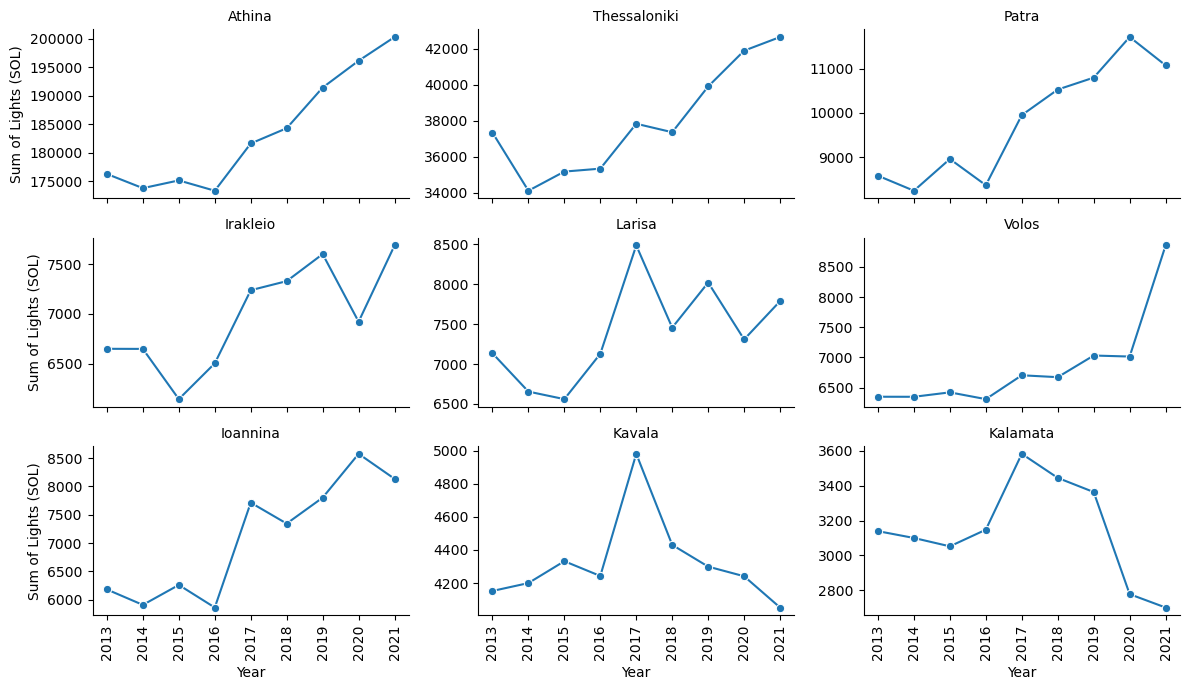

In [12]:

# βεβαιωνόμαστε ότι η στήλη 'year' είναι αριθμητική για να μπορεί να χρησιμοποιηθεί στον άξονα x των γραφημάτων
greece_df['year'] = pd.to_numeric(greece_df['year'])


# Δημιουργούμε ένα FacetGrid με seaborn, όπου κάθε διάγραμμα αντιστοιχεί σε ένα FUA (fua_name)
g = sns.FacetGrid(greece_df, col="fua_name", col_wrap=3, height=4, sharey=False)

# για κάθε subplot, σχεδιάζουμε ένα lineplot με x=year και y=sum, και προσθέτουμε markers στα σημεία δεδομένων
g.map_dataframe(sns.lineplot, x="year", y="sum", marker="o")

# παραμετροποιούμε τους άξονες και τους τίτλους για καλύτερη εμφάνιση
g.set(xticks=sorted(greece_df['year'].unique()))
g.set_xticklabels(sorted(greece_df['year'].unique()), rotation=90)
g.set_axis_labels("Year", "Sum of Lights (SOL)")
g.set_titles(col_template="{col_name}")

g.figure.set_size_inches(12, 7)
plt.tight_layout()


# Αποθήκευση του γραφήματος σε αρχείο PNG με υψηλή ανάλυση (300 dpi)
plt.savefig(OUTPUT_DIR / 'FUA_SOL_Analysis.png', dpi=300, bbox_inches='tight')


plt.show()

# Παράδειγμα 2: Hierarchical zonal statistics

Να υπολογιστεί για κάθε FUA, για κάθε έτος και για κάθε χρήση γης το άθροισμα (SoL) και ο μέσος όρος της ακτινοβολίας νυκτερινών φώτων.

In [ ]:

# ESA WorldCover 10m v200 (2021)
world_cover = ee.Image("ESA/WorldCover/v200/2021")




# ορισμός των Land Cover Classes
classes = ee.List([10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100])
class_names = ee.Dictionary({
    10: 'Tree cover', 20: 'Shrubland', 30: 'Grassland', 40: 'Cropland',
    50: 'Built-up', 60: 'Bare / sparse vegetation', 70: 'Snow and ice', 80: 'Permanent water bodies',
    90: 'Herbaceous wetland', 95: 'Mangroves', 100: 'Moss and lichen'
})

def process_year(viirs_image):
    """για κάθε εικόνα VIIRS, υπολογίζει για κάθε κάλυψη γης κάθε FUA γεωμετρία"""

    # λήψη του έτους από την εικόνα
    year = viirs_image.date().get('year')
    
    # επιλογή της κατάλληλης μπάντας (average_masked) από την εικόνα VIIRS
    light_band = viirs_image.select('average_masked') 
    
    def process_class(class_val):
        """"Διαδικασία για κάθε κατηγορία κάλυψης γης: δημιουργία μάσκας, εφαρμογή της στα φώτα, και υπολογισμός sum και mean ανά FUA"""
       
        # δημιουργία μάσκας για την συγκεκριμένη κατηγορία κάλυψης γης
        mask = world_cover.eq(ee.Number(class_val))
        masked_lights = light_band.updateMask(mask)
        
        sum_reducer = ee.Reducer.sum()
        mean_reducer = ee.Reducer.mean()
        combined_reducer = sum_reducer.combine(reducer2=mean_reducer, sharedInputs=True)
        
        stats = masked_lights.reduceRegions(
            collection=fua,
            reducer=combined_reducer,
            scale=463,
            crs='EPSG:4326',
            tileScale = 16,
        )
        
        # Προσθέτουμε το έτος, την κατηγορία κάλυψης γης, και άλλα μεταδεδομένα σε κάθε αποτέλεσμα
        return stats.map(lambda f: f.set({
            'year': year,
            'lc_class': class_val,
            'lc_name': class_names.get(class_val),
            # 'fua_name': f.get('fua_name'),
            # 'country': f.get('country')
        }))

    # εκτέλεση  για κάθε κατηγορία κάλυψης γης και συλλογή των αποτελεσμάτων
    class_results = classes.map(process_class)
    return ee.FeatureCollection(class_results).flatten()

# εκτέλεση για όλη την χρονοσειρά των VIIRS εικόνων και συλλογή των αποτελεσμάτων
full_results = viirs_col.map(process_year).flatten()



# εξαγωγή σε CSV
task = ee.batch.Export.table.toDrive(
    collection=full_results,
    description='FUA_SOL_by_LandCover_Yearly',
    
    fileFormat='CSV',
    selectors=['country','fua_name','fua_code',  'year', 'lc_class', 'lc_name', 'mean', 'sum'] # επιλέγουμε ποιες ιδιότητες θα συμπεριληφθούν στο CSV σαν στήλες
)

task.start()


# Παράδειγμα 3: Point sampling

στα όρια των NUTS2 να παράγετε τυχαία 1000 σημεία και με βάση αυτά τα σημεία να πάρετε δείγματα για κάθε μήνα για την περίοδο 2020-2026 από το dataset: 
[MOD21C3.061 Terra Land Surface Temperature and 3-Band Emissivity Monthly L3 Global 0.05 Deg CMG](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD21C3)

In [18]:

# Ορισμός της χρονικής περιόδου
START_DATE = '2020-01-01'
END_DATE = '2026-01-01' 

# Αριθμός τυχαίων σημείων
NUM_POINTS = 1000

# Το dataset MODIS (Land Surface Temperature/Emissivity Monthly)
MODIS_COLLECTION_ID = "MODIS/061/MOD21C3"

# Επιλέγουμε τη ζώνη της ημερήσιας θερμοκρασίας (LST_Day)
# Οι τιμές είναι σε Kelvin και έχουν scale factor 0.02
BANDS = ['LST_Day', 'LST_Night'] 




# Φόρτωση των NUTS2 
nuts_level2 = ee.FeatureCollection('projects/civic-meridian-417810/assets/NUTS_RG_01M_2021_4326_LEVL_2')

# επιλογή 1000 τυχαίων σημείων εντός των ορίων όNUTS2
random_points = ee.FeatureCollection.randomPoints(
    region=nuts_level2.geometry(), 
    points=NUM_POINTS, 
    seed=42 # Για σταθερά αποτελέσματα σε κάθε εκτέλεση
)

# Προσθέτουμε ένα μοναδικό ID σε κάθε σημείο για να μπορούμε να τα αναγνωρίσουμε μετά τη δειγματοληψία
random_points = random_points.map(
    lambda f: f.set('point_id', f.id())
)



# Φορτώνουμε τη συλλογή MODIS, φιλτράρουμε ημερομηνίες και επιλέγουμε τη ζώνη
modis_col = ee.ImageCollection(MODIS_COLLECTION_ID) \
    .filterDate(START_DATE, END_DATE) 




In [19]:


# Για κάθε εικόνα στη συλλογή, παίρνουμε δείγμα από όλα τα σημεία ταυτόχρονα.

def sample_at_points(image):

    image = ee.Image(image).select(BANDS)
    
    # μετατραπή από ακέραιοι σε Kelvin με εφαρμογή του scale factor
    scaled_image =   ee.Image(image.multiply(0.02).copyProperties(image, ['system:time_start'])) # SOS casting σε ee.Image 

    # μετατροπή από Kelvin σε Celsius προαιρετικά, αν θέλουμε να δουλέψουμε με βαθμούς Κελσίου αντί για Kelvin
    # scaled_image = scaled_image.subtract(273.15).copyProperties(image, ['system:time_start'])


    # Παίρνουμε την ημερομηνία της εικόνας
    date = ee.Date(scaled_image.get('system:time_start')).format('YYYY-MM-dd')

    # Εκτελούμε τη δειγματοληψία (sampleRegions)
    # Scale=5600m γιατί η ανάλυση του MOD21C3 είναι 0.05 μοίρες (~5.6km)
    sampled_features = ee.FeatureCollection(scaled_image.sampleRegions(
        collection=random_points,
        properties=['point_id'], # το properties είναι μια λίστα στην οποία δηλώνουμε ποια properties θέλουμε να κρατήσουμε από τα random points, (δεν κρατάμε κανένα εδώ)
        geometries=True # Κρατάμε τις συντεταγμένες
    ))

    # Προσθέτουμε την ημερομηνία ως ιδιότητα σε κάθε σημείο 
    
    return  sampled_features.map(lambda f: f.set({
        'date': date
        }))

# Εφαρμογή της συνάρτησης σε όλη τη συλλογή
samples = modis_col.map(sample_at_points).flatten()

# προσθήκη των γεωγραφικών συντεταγμένων ως ιδιότητες
final_samples = samples.map(lambda f: f.set({
    'lon': f.geometry().coordinates().get(0),
    'lat': f.geometry().coordinates().get(1)
}))


task = ee.batch.Export.table.toDrive(
    collection=final_samples,
    description='MODIS_LST_Sampling_2020_2026',
    fileFormat='GeoJSON',
    folder='GEE_Exports', 
    selectors=['.geo','point_id', 'date', 'LST_Day', 'LST_Night', 'lon', 'lat'] # στήλες για εξαγωγή
)

# 2. Εκκίνηση της εργασίας
task.start()

